### Ouverture des fichiers et jointures 

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from pathlib import Path
from fonction import *
import seaborn as sns
import numpy as np



l’indice d’humidité des sols SWI est défini comme suit :

SWI = (W - Wwilt) / (Wfc - Wwilt)

où W est le contenu intégré en eau du sol, Wwilt le contenu en eau au point de flétrissement et Wfc le contenu en eau du sol à la capacité au champ.

Le SWI vaut 0 pour un sol très sec (et peut être négatif pour un sol extrêmement sec), il atteint la valeur de 1 pour un sol à capacité au champ, dépasse 1 pour des sols très humides, et est borné à une valeur correspondant à la saturation (dépendante de la composition du sol présent en chaque point de grille).  

 

In [2]:
### Importation des données ###


# Données communes
fp = Path('/Users/fadibelmahi/Desktop/data copie/raw/communes/ADE_4-0_GPKG_WGS84G_FRA-ED2025-11-20.gpkg')
if not fp.exists():
	raise FileNotFoundError(f"File not found: {fp.resolve()}")
communes = gpd.read_file(fp, layer='commune')



# Données SWI uniforme
fp = Path('/Users/fadibelmahi/Desktop/data copie/processed/jointure_meteo_swi_argile_nearest.gpkg')
if not fp.exists():
    raise FileNotFoundError(f"File not found: {fp.resolve()}")
gdf_joint_argile= gpd.read_file(fp)



In [3]:
### Affichage des données de communes ###


display(communes.head())

,cleabs,nom_officiel,nom_officiel_en_majuscules,statut,code_insee,population,date_du_recensement,organisme_recenseur,code_insee_du_canton,code_insee_de_l_arrondissement,code_insee_du_departement,code_insee_de_la_region,codes_siren_des_epci,code_siren,code_postal,superficie_cadastrale,geometry
0,COMMUNE_0000000000001001,L'Abergement-Clémenciat,L'ABERGEMENT-CLEMENCIAT,Commune simple,01001,859,2022-01-01,INSEE,0108,012,01,84,200069193,210100012,01400,1590,"MULTIPOLYGON (((4.95841 46.15327, 4.95812 46.1..."
1,COMMUNE_0000000000001002,L'Abergement-de-Varey,L'ABERGEMENT-DE-VAREY,Commune simple,01002,273,2022-01-01,INSEE,0101,011,01,84,240100883,210100020,01640,920,"MULTIPOLYGON (((5.4302 45.98277, 5.43012 45.98..."
2,COMMUNE_0000000000001004,Ambérieu-en-Bugey,AMBERIEU-EN-BUGEY,Commune simple,01004,15554,2022-01-01,INSEE,0101,011,01,84,240100883,210100046,01500,2460,"MULTIPOLYGON (((5.40882 45.94206, 5.4085 45.94..."
3,COMMUNE_0000000000001005,Ambérieux-en-Dombes,AMBERIEUX-EN-DOMBES,Commune simple,01005,1917,2022-01-01,INSEE,0122,012,01,84,200042497,210100053,01330,1590,"MULTIPOLYGON (((4.94298 45.97962, 4.94257 45.9..."
4,COMMUNE_0000000000001006,Ambléon,AMBLEON,Commune simple,01006,114,2022-01-01,INSEE,0104,011,01,84,200040350,210100061,01300,590,"MULTIPOLYGON (((5.57083 45.75338, 5.57219 45.7..."


In [6]:
### Affichage des données de SWI mensuel ###


df = gdf_joint_argile

In [9]:
# Création d'un jeu de données fictif reproduisant la structure de votre base
np.random.seed(42)
dates = pd.date_range(start="1980-01-01", periods=480, freq="ME")
df = pd.DataFrame({
    'NUMERO': 4390, # Maille géographique Météo-France
    'DATE': dates,
    'SWI_UNIF_MENS': np.clip(np.random.beta(2, 5, 480), 0, 1)
})

# --- CORRECTION DE L'ERREUR ICI ---
# On cible explicitement la colonne 'DATE' pour utiliser l'accesseur.dt
df['Mois'] = df['DATE'].dt.month 

# Focus sur la saison estivale agricole (Mai à Août)
df_ete = df[df['Mois'].isin([1, 2, 3, 4])].copy()
swi_data = df_ete.values

In [ ]:
print("--- 3.1 Descriptive statistics ---")
print(f"Mean: {np.mean(swi_data):.4f}")
print(f"Variance: {np.var(swi_data):.4f}")
print(f"Quantiles (25%, 50%, 75%): {np.percentile(swi_data, )}")
print(f"Skewness: {stats.skew(swi_data):.4f}")
print(f"Kurtosis: {stats.kurtosis(swi_data):.4f}")
print(f"Extreme values (Min, Max): {np.min(swi_data):.4f}, {np.max(swi_data):.4f}")

# Graphiques de distribution
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
sns.histplot(swi_data, kde=False, stat="density", ax=axes, color='skyblue')
axes.set_title('Histogram')

sns.kdeplot(swi_data, ax=axes[5], color='red', fill=True)
axes.[5] set_title('KDE')

stats.probplot(swi_data, dist="norm", plot=axes[6])
axes.[6]set_title('QQ plot')

sns.boxplot(x=swi_data, ax=axes[7], color='lightgreen')
axes.[7]set_title('Boxplot')
plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (1846904756.py, line 15)

### Statistiques descriptives

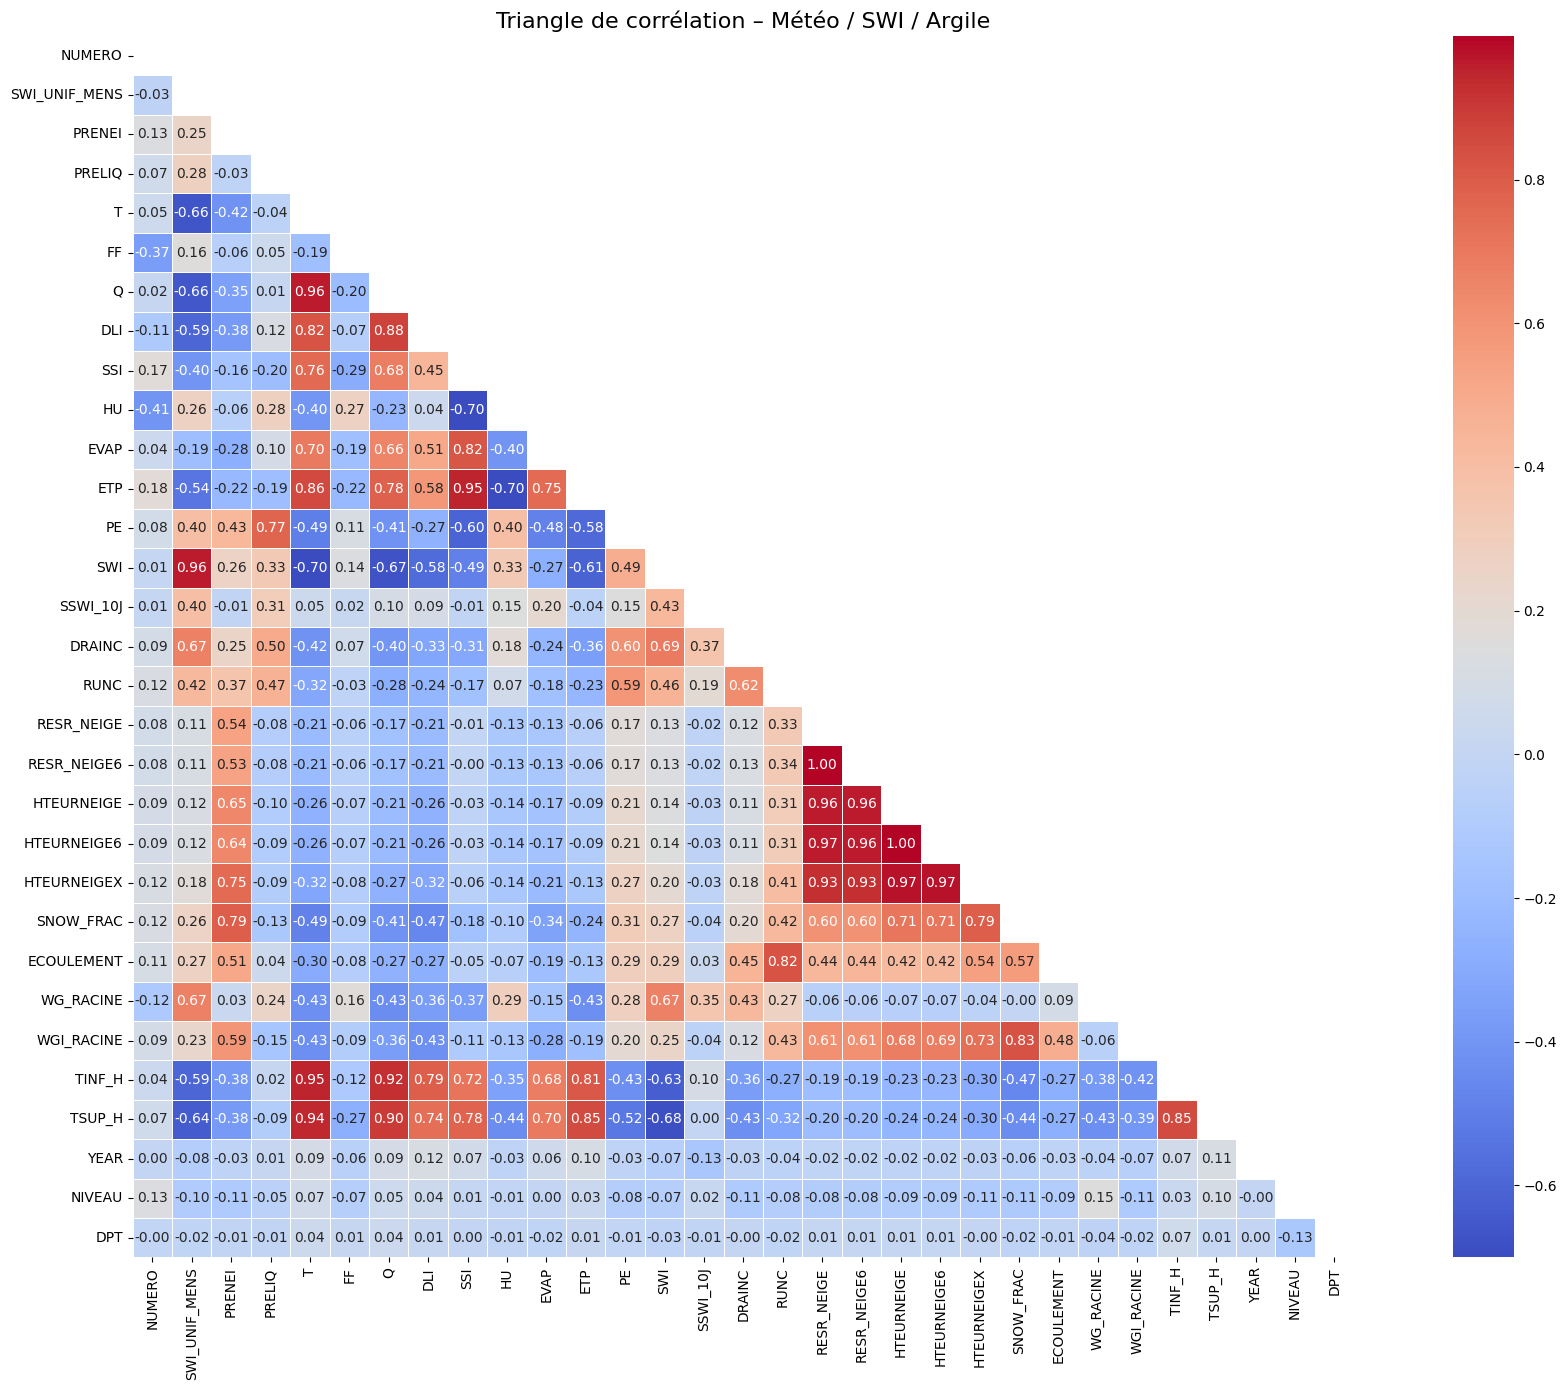

Top 10 des plus grandes corrélations avec la variable SWI :
SWI_UNIF_MENS    0.960589
T                0.695947
DRAINC           0.693557
TSUP_H           0.681959
WG_RACINE        0.670207
Q                0.668955
TINF_H           0.628107
ETP              0.607758
DLI              0.579849
SSI              0.493160
Name: SWI, dtype: float64


In [ ]:


numeric_cols = gdf_joint_argile.select_dtypes(include=[np.number])

# Optionnel : enlever colonnes purement techniques
cols_to_exclude = ["LAMBX", "LAMBY", "dist_to_argile"]
numeric_cols = numeric_cols.drop(
    columns=[c for c in cols_to_exclude if c in numeric_cols.columns]
)


corr_matrix = numeric_cols.corr()



mask = np.triu(np.ones_like(corr_matrix, dtype=bool))



plt.figure(figsize=(20, 14))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=True,
    linewidths=0.5
)

plt.title("Triangle de corrélation – Météo / SWI / Argile", fontsize=16)
plt.tight_layout()
plt.show()

# Calculer les corrélations absolues avec la variable 'SWI'
correlations = corr_matrix['SWI'].abs().sort_values(ascending=False)

# Extraire les 10 plus grandes corrélations (en excluant 'SWI' lui-même)
top_10_correlations = correlations.drop('SWI').head(10)

# Afficher les résultats
print("Top 10 des plus grandes corrélations avec la variable SWI :")
print(top_10_correlations)

### Visualisation des regions étudiées 

In [13]:


# Table officielle DPT -> Région (France métropolitaine)
dpt_to_region = {
    # Auvergne-Rhône-Alpes
    "01": "Auvergne-Rhône-Alpes", "03": "Auvergne-Rhône-Alpes",
    "07": "Auvergne-Rhône-Alpes", "15": "Auvergne-Rhône-Alpes",
    "26": "Auvergne-Rhône-Alpes", "38": "Auvergne-Rhône-Alpes",
    "42": "Auvergne-Rhône-Alpes", "43": "Auvergne-Rhône-Alpes",
    "63": "Auvergne-Rhône-Alpes", "69": "Auvergne-Rhône-Alpes",
    "73": "Auvergne-Rhône-Alpes", "74": "Auvergne-Rhône-Alpes",

    # Bourgogne-Franche-Comté
    "21": "Bourgogne-Franche-Comté", "25": "Bourgogne-Franche-Comté",
    "39": "Bourgogne-Franche-Comté", "58": "Bourgogne-Franche-Comté",
    "70": "Bourgogne-Franche-Comté", "71": "Bourgogne-Franche-Comté",
    "89": "Bourgogne-Franche-Comté", "90": "Bourgogne-Franche-Comté",

    # Bretagne
    "22": "Bretagne", "29": "Bretagne",
    "35": "Bretagne", "56": "Bretagne",

    # Centre-Val de Loire
    "18": "Centre-Val de Loire", "28": "Centre-Val de Loire",
    "36": "Centre-Val de Loire", "37": "Centre-Val de Loire",
    "41": "Centre-Val de Loire", "45": "Centre-Val de Loire",

    # Corse
    "2A": "Corse", "2B": "Corse",

    # Grand Est
    "08": "Grand Est", "10": "Grand Est", "51": "Grand Est",
    "52": "Grand Est", "54": "Grand Est", "55": "Grand Est",
    "57": "Grand Est", "67": "Grand Est", "68": "Grand Est",
    "88": "Grand Est",

    # Hauts-de-France
    "02": "Hauts-de-France", "59": "Hauts-de-France",
    "60": "Hauts-de-France", "62": "Hauts-de-France",
    "80": "Hauts-de-France",

    # Île-de-France
    "75": "Île-de-France", "77": "Île-de-France",
    "78": "Île-de-France", "91": "Île-de-France",
    "92": "Île-de-France", "93": "Île-de-France",
    "94": "Île-de-France", "95": "Île-de-France",

    # Normandie
    "14": "Normandie", "27": "Normandie",
    "50": "Normandie", "61": "Normandie",
    "76": "Normandie",

    # Nouvelle-Aquitaine
    "16": "Nouvelle-Aquitaine", "17": "Nouvelle-Aquitaine",
    "19": "Nouvelle-Aquitaine", "23": "Nouvelle-Aquitaine",
    "24": "Nouvelle-Aquitaine", "33": "Nouvelle-Aquitaine",
    "40": "Nouvelle-Aquitaine", "47": "Nouvelle-Aquitaine",
    "64": "Nouvelle-Aquitaine", "79": "Nouvelle-Aquitaine",
    "86": "Nouvelle-Aquitaine", "87": "Nouvelle-Aquitaine",

    # Occitanie
    "09": "Occitanie", "11": "Occitanie", "12": "Occitanie",
    "30": "Occitanie", "31": "Occitanie", "32": "Occitanie",
    "34": "Occitanie", "46": "Occitanie", "48": "Occitanie",
    "65": "Occitanie", "66": "Occitanie", "81": "Occitanie",
    "82": "Occitanie",

    # Pays de la Loire
    "44": "Pays de la Loire", "49": "Pays de la Loire",
    "53": "Pays de la Loire", "72": "Pays de la Loire",
    "85": "Pays de la Loire",

    # Provence-Alpes-Côte d’Azur
    "04": "Provence-Alpes-Côte d’Azur", "05": "Provence-Alpes-Côte d’Azur",
    "06": "Provence-Alpes-Côte d’Azur", "13": "Provence-Alpes-Côte d’Azur",
    "83": "Provence-Alpes-Côte d’Azur", "84": "Provence-Alpes-Côte d’Azur",
}



In [7]:
# S'assurer que DPT est bien une string à 2 caractères
gdf_joint_argile["DPT"] = gdf_joint_argile["DPT"].astype(str).str.zfill(2)

# Ajout de la colonne REGION
gdf_joint_argile["REGION"] = gdf_joint_argile["DPT"].map(dpt_to_region)

# Départements non reconnus
missing = gdf_joint_argile[gdf_joint_argile["REGION"].isna()]["DPT"].unique()
print("Départements non mappés :", missing)

# Comptage par région
gdf_joint_argile["REGION"].value_counts()

Départements non mappés : <StringArray>
['202', '201']
Length: 2, dtype: str


REGION
Nouvelle-Aquitaine            1071720
Occitanie                      931320
Auvergne-Rhône-Alpes           885300
Grand Est                      742560
Bourgogne-Franche-Comté        598260
Centre-Val de Loire            478920
Provence-Alpes-Côte d’Azur     428220
Pays de la Loire               414960
Hauts-de-France                410280
Normandie                      386100
Bretagne                       379080
Île-de-France                  147420
Name: count, dtype: int64

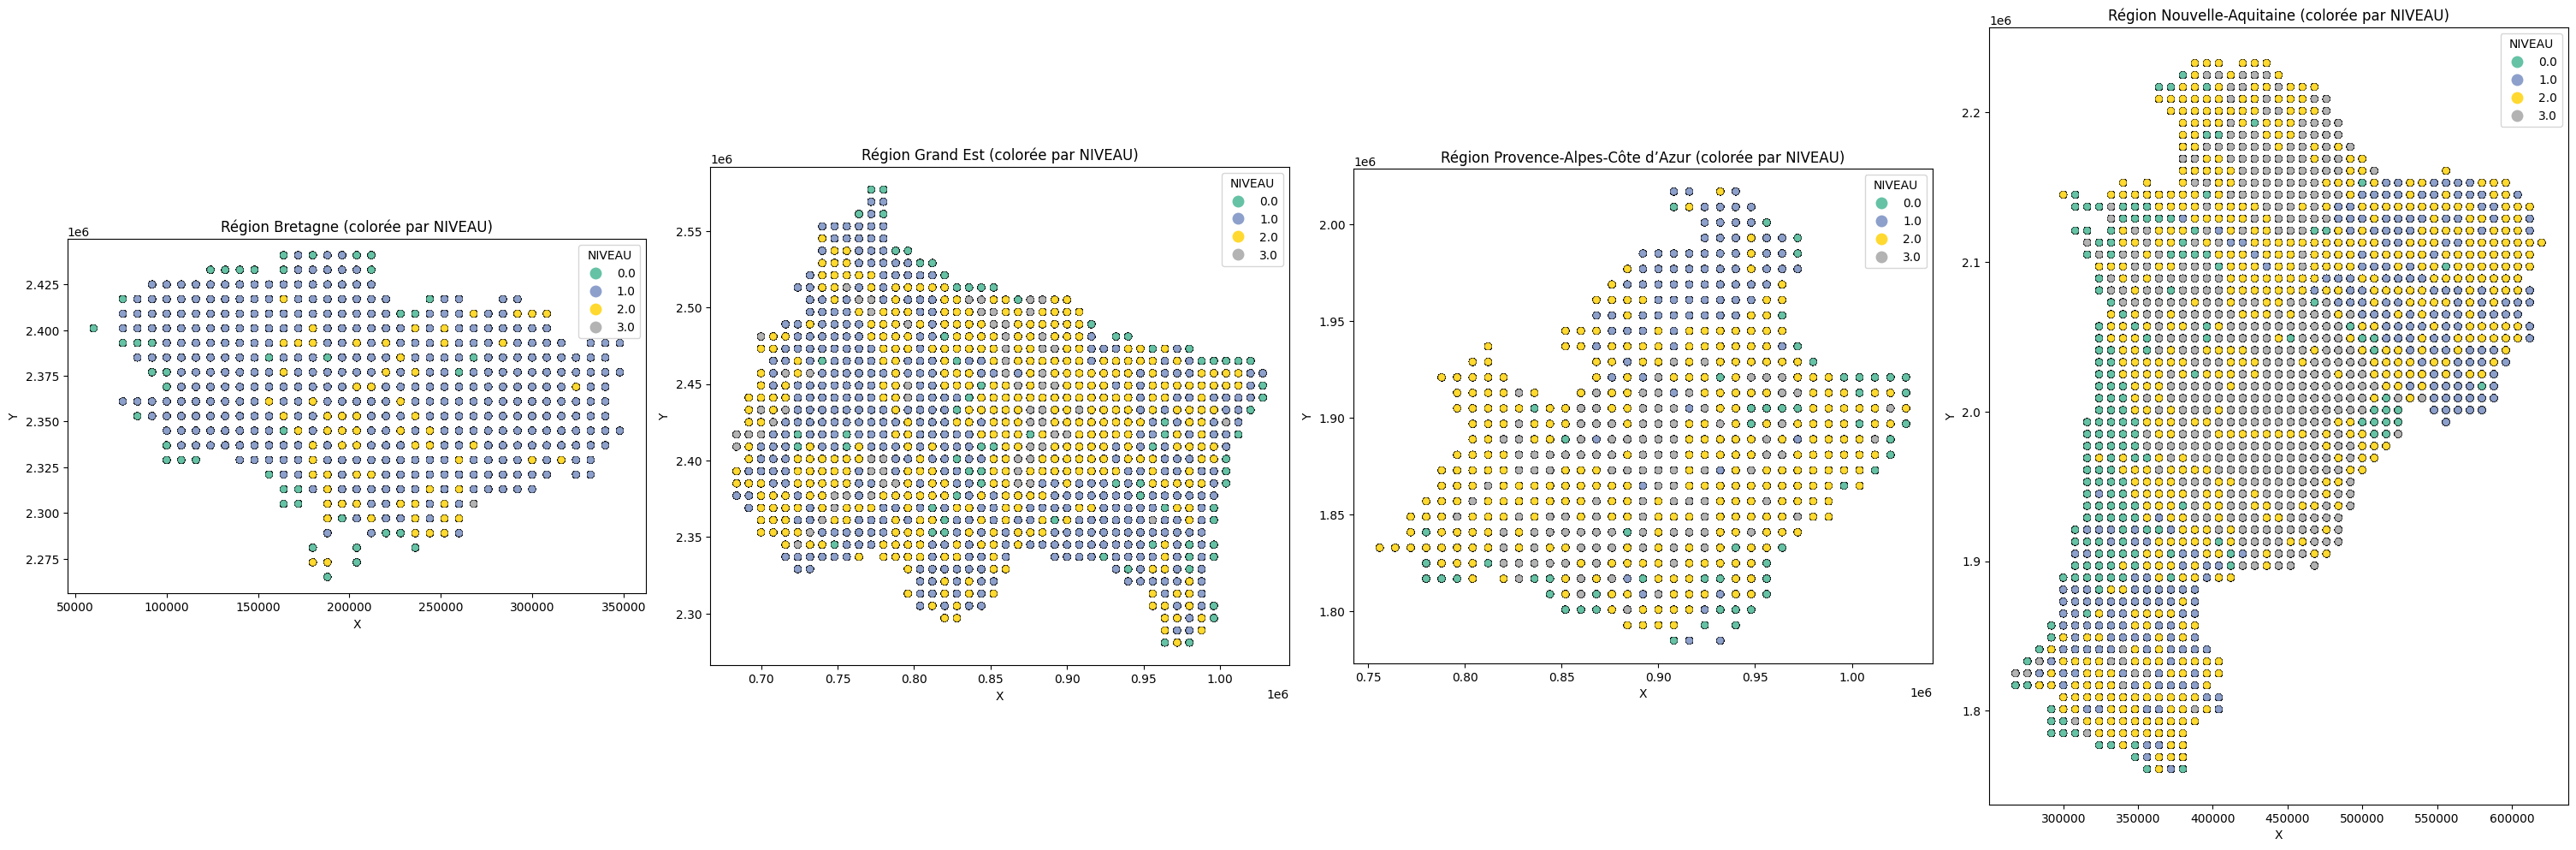

In [8]:
# Régions à afficher (basées sur la colonne REGION)
regions = [
    "Bretagne",
    "Grand Est",
    "Provence-Alpes-Côte d’Azur",
    "Nouvelle-Aquitaine"
]

# Création de la figure
fig, axes = plt.subplots(1, 4, figsize=(30, 15), constrained_layout=True)
for ax, region_name in zip(axes, regions):

    selected = gdf_joint_argile[gdf_joint_argile["REGION"] == region_name].copy()

    if selected.empty:
        print(f"Aucune géométrie pour la région {region_name}.")
        ax.set_title(f"{region_name} (Aucune donnée)")
        ax.axis("off")
        continue

    # Assurer NIVEAU comme variable catégorielle
    selected["NIVEAU"] = selected["NIVEAU"].astype("category")

    selected.plot(
        column="NIVEAU",
        cmap="Set2",
        legend=True,
        legend_kwds={"title": "NIVEAU"},
        ax=ax,
        edgecolor="black",
        linewidth=0.2
    )

    ax.set_title(f"Région {region_name} (colorée par NIVEAU)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

plt.show()

In [ ]:
gdf_joint_argile.crs

<Projected CRS: EPSG:27572>
Name: NTF (Paris) / Lambert zone II
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: France mainland onshore between 50.5 grads and 53.5 grads North (45°27'N to 48°09'N). Also used over all onshore mainland France.
- bounds: (-4.87, 42.33, 8.23, 51.14)
Coordinate Operation:
- name: Lambert zone II
- method: Lambert Conic Conformal (1SP)
Datum: Nouvelle Triangulation Francaise (Paris)
- Ellipsoid: Clarke 1880 (IGN)
- Prime Meridian: Paris

In [ ]:
communes.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
gdf_joint_argile

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,WGI_RACINE,TINF_H,TSUP_H,YEAR,ALEA,NIVEAU,DPT,dist_to_argile,geometry,REGION
0,3827,773980,6713410,1960-12-01,0.982,5.7,59.2,1.941935,3.132258,4.049000,...,0.003516,-5.7,12.0,1960,Moyen,2.0,89,0.000000,POINT (723999.802 2280998.23),Bourgogne-Franche-Comté
1,3826,765986,6713478,1960-12-01,0.977,4.8,58.9,2.216129,3.254839,4.104935,...,0.002323,-5.4,12.3,1960,Moyen,2.0,89,0.000000,POINT (715999.436 2280998.385),Bourgogne-Franche-Comté
2,3825,757993,6713546,1960-12-01,0.973,4.4,58.9,2.338710,3.300000,4.130161,...,0.001806,-5.2,12.4,1960,Moyen,2.0,89,0.000000,POINT (708000.072 2280998.598),Bourgogne-Franche-Comté
3,3824,749999,6713614,1960-12-01,0.973,4.4,58.9,2.338710,3.300000,4.130161,...,0.001806,-5.2,12.4,1960,Faible,1.0,89,0.000000,POINT (699999.708 2280998.852),Bourgogne-Franche-Comté
4,5323,717146,6609971,1960-09-01,0.449,0.0,73.6,13.356667,1.530000,8.058967,...,0.000000,2.3,24.0,1960,Moyen,2.0,03,0.000000,POINT (667998.94 2176998.552),Auvergne-Rhône-Alpes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7005175,7245,363949,6429068,2024-08-01,0.124,0.0,37.5,20.451613,1.880645,11.601839,...,0.000000,9.6,37.0,2024,Aucun,0.0,33,24729.333576,POINT (315997.597 1992998.292),Nouvelle-Aquitaine
7005176,7245,363949,6429068,2024-03-01,1.042,0.0,160.8,10.851613,2.603226,6.793806,...,0.000000,2.0,22.7,2024,Aucun,0.0,33,24729.333576,POINT (315997.597 1992998.292),Nouvelle-Aquitaine
7005177,7245,363949,6429068,2024-12-01,0.695,0.0,72.5,8.048387,2.909677,5.864935,...,0.000000,0.8,16.1,2024,Aucun,0.0,33,24729.333576,POINT (315997.597 1992998.292),Nouvelle-Aquitaine
7005178,7245,363949,6429068,2024-05-01,0.770,0.0,94.9,15.264516,2.796774,8.711000,...,0.000000,9.2,27.6,2024,Aucun,0.0,33,24729.333576,POINT (315997.597 1992998.292),Nouvelle-Aquitaine


### FOCUS à l'echelle de la France

,SWI_UNIF_MENS
count,7.005180e+06
mean,6.137139e-01
median,6.620000e-01
std,3.272674e-01
variance,1.071039e-01
min,-5.700000e-02
max,1.542000e+00
q01,-6.000000e-03
q05,6.400000e-02
q25,3.250000e-01


,test,statistique,p_value
0,D’Agostino K²,138850.894926,0.000000e+00
1,Jarque-Bera,13808.250642,0.000000e+00
2,Shapiro-Wilk,0.945199,1.254962e-39


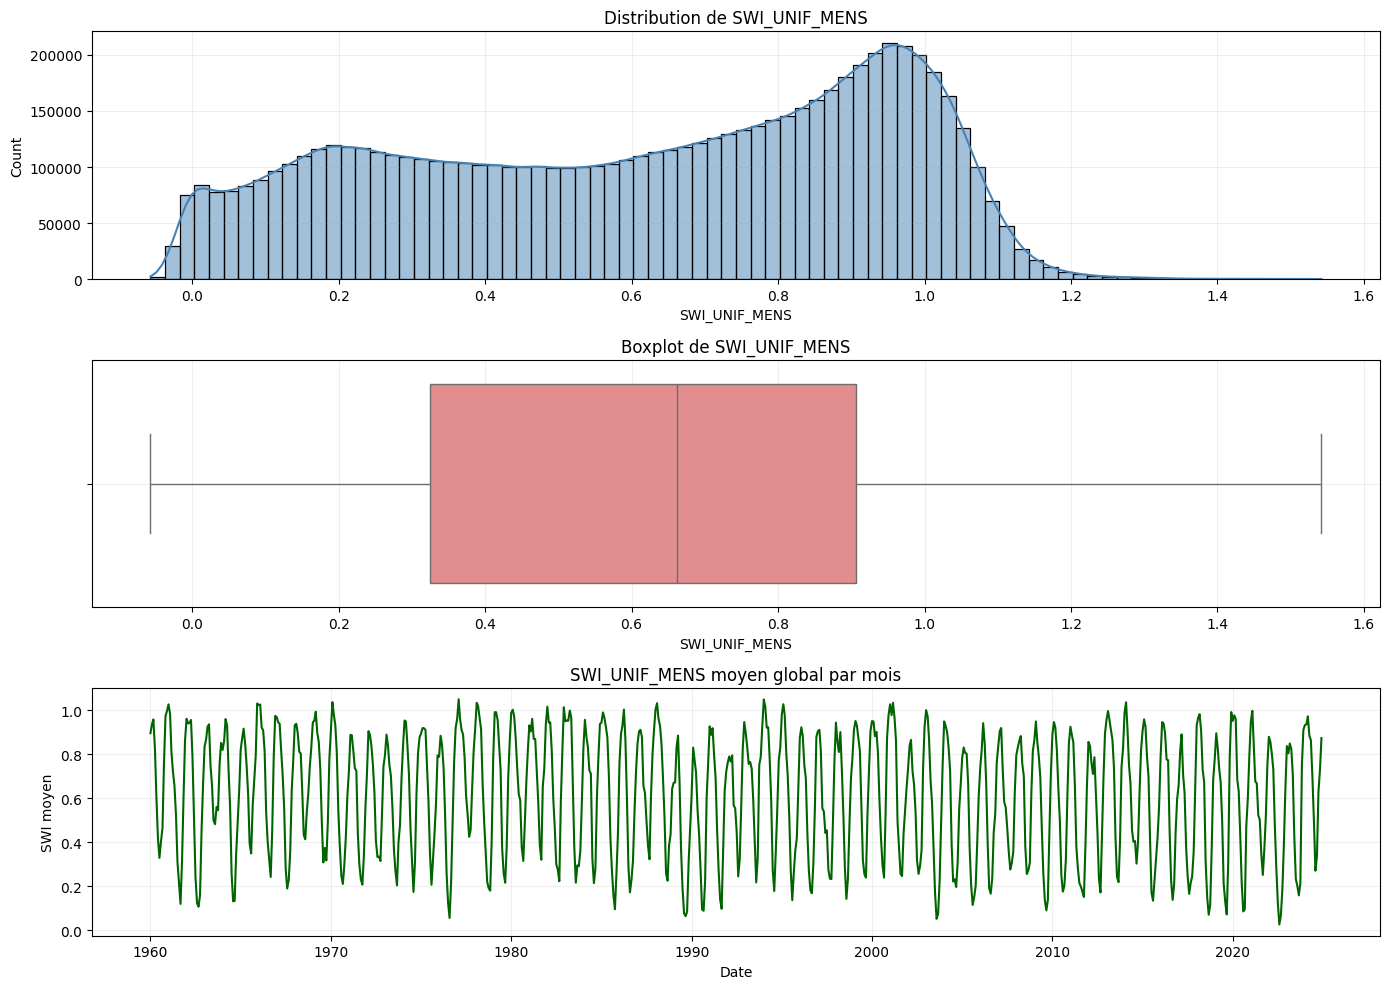

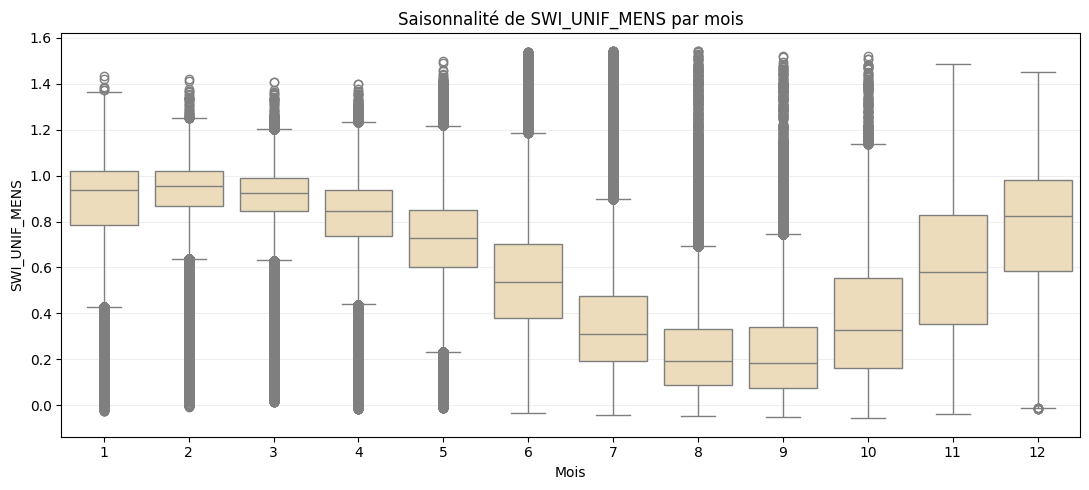

In [11]:
from scipy import stats

# --- Préparation des données ---
eda = gdf_joint_argile[["DATE", "SWI_UNIF_MENS"]].copy()
eda["DATE"] = pd.to_datetime(eda["DATE"], errors="coerce")
eda["SWI_UNIF_MENS"] = pd.to_numeric(eda["SWI_UNIF_MENS"], errors="coerce")
eda = eda.dropna(subset=["DATE", "SWI_UNIF_MENS"])

swi = eda["SWI_UNIF_MENS"]

# --- Statistiques descriptives ---
desc = swi.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
iqr = desc["75%"] - desc["25%"]
lower = desc["25%"] - 1.5 * iqr
upper = desc["75%"] + 1.5 * iqr
outlier_rate = ((swi < lower) | (swi > upper)).mean() * 100

stats_table = pd.Series(
    {
        "count": swi.count(),
        "mean": swi.mean(),
        "median": swi.median(),
        "std": swi.std(),
        "variance": swi.var(),
        "min": swi.min(),
        "max": swi.max(),
        "q01": desc["1%"],
        "q05": desc["5%"],
        "q25": desc["25%"],
        "q50": desc["50%"],
        "q75": desc["75%"],
        "q95": desc["95%"],
        "q99": desc["99%"],
        "IQR": iqr,
        "skewness": swi.skew(),
        "kurtosis_fisher": swi.kurt(),        # 0 = normale
        "kurtosis_pearson": swi.kurt() + 3,   # 3 = normale
        "outlier_rate_IQR_%": outlier_rate,
    },
    name="SWI_UNIF_MENS"
)

display(stats_table.to_frame())

# --- Tests de normalité (sur échantillon pour performance) ---
sample_n = min(200_000, len(swi))
sample = swi.sample(sample_n, random_state=42)

k2_stat, k2_p = stats.normaltest(sample)          # D’Agostino K²
jb_stat, jb_p = stats.jarque_bera(sample)

# Shapiro recommandé <= 5000
shapiro_sample = sample.sample(min(5000, len(sample)), random_state=42)
sh_stat, sh_p = stats.shapiro(shapiro_sample)

normality = pd.DataFrame(
    {
        "test": ["D’Agostino K²", "Jarque-Bera", "Shapiro-Wilk"],
        "statistique": [k2_stat, jb_stat, sh_stat],
        "p_value": [k2_p, jb_p, sh_p],
    }
)
display(normality)

# --- Visualisations ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10), squeeze=False)

# Histogramme + KDE
sns.histplot(swi, bins=80, kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Distribution de SWI_UNIF_MENS")
axes[0, 0].set_xlabel("SWI_UNIF_MENS")
axes[0, 0].grid(alpha=0.2)

# Boxplot
sns.boxplot(x=swi, ax=axes[1, 0], color="lightcoral")
axes[1, 0].set_title("Boxplot de SWI_UNIF_MENS")
axes[1, 0].set_xlabel("SWI_UNIF_MENS")
axes[1, 0].grid(alpha=0.2)



# Série temporelle moyenne mensuelle (global)
swi_monthly_global = eda.groupby(pd.Grouper(key="DATE", freq="MS"))["SWI_UNIF_MENS"].mean()
axes[2, 0].plot(swi_monthly_global.index, swi_monthly_global.values, color="darkgreen", linewidth=1.5)
axes[2, 0].set_title("SWI_UNIF_MENS moyen global par mois")
axes[2, 0].set_xlabel("Date")
axes[2, 0].set_ylabel("SWI moyen")
axes[2, 0].grid(alpha=0.2)

plt.tight_layout()
plt.show()

# --- Saisonnalité (mois) ---
eda["month"] = eda["DATE"].dt.month
plt.figure(figsize=(11, 5))
sns.boxplot(data=eda, x="month", y="SWI_UNIF_MENS", color="wheat")
plt.title("Saisonnalité de SWI_UNIF_MENS par mois")
plt.xlabel("Mois")
plt.ylabel("SWI_UNIF_MENS")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

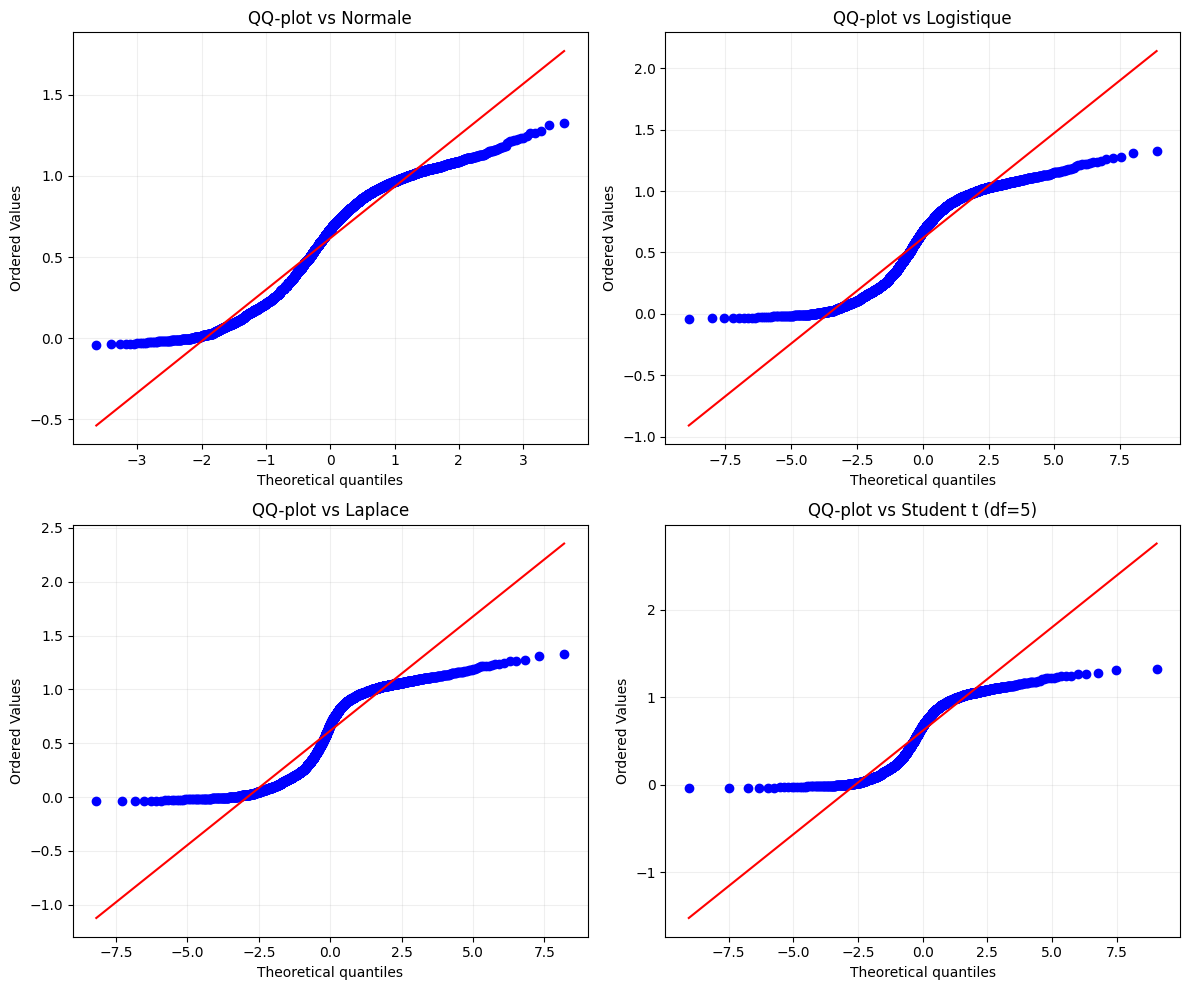

In [7]:
# QQ-plots de SWI_UNIF_MENS contre plusieurs distributions
data_qq = shapiro_sample.dropna()

distributions = [
    ("Normale", stats.norm, ()),
    ("Logistique", stats.logistic, ()),
    ("Laplace", stats.laplace, ()),
    ("Student t (df=5)", stats.t, (5,)),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, dist, sparams) in zip(axes.flat, distributions):
    stats.probplot(data_qq, dist=dist, sparams=sparams, plot=ax)
    ax.set_title(f"QQ-plot vs {name}")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### FOCUS sur la regions Nouvelle aquitaine

,SWI_UNIF_MENS (Nouvelle-Aquitaine)
count,1.071720e+06
mean,6.087545e-01
median,6.590000e-01
std,3.357895e-01
variance,1.127546e-01
min,-3.300000e-02
max,1.354000e+00
q01,1.000000e-03
q05,5.900000e-02
q25,3.010000e-01


,test,statistique,p_value
0,D’Agostino K²,462629.019085,0.000000e+00
1,Jarque-Bera,15490.029422,0.000000e+00
2,Shapiro-Wilk,0.937116,1.003434e-41


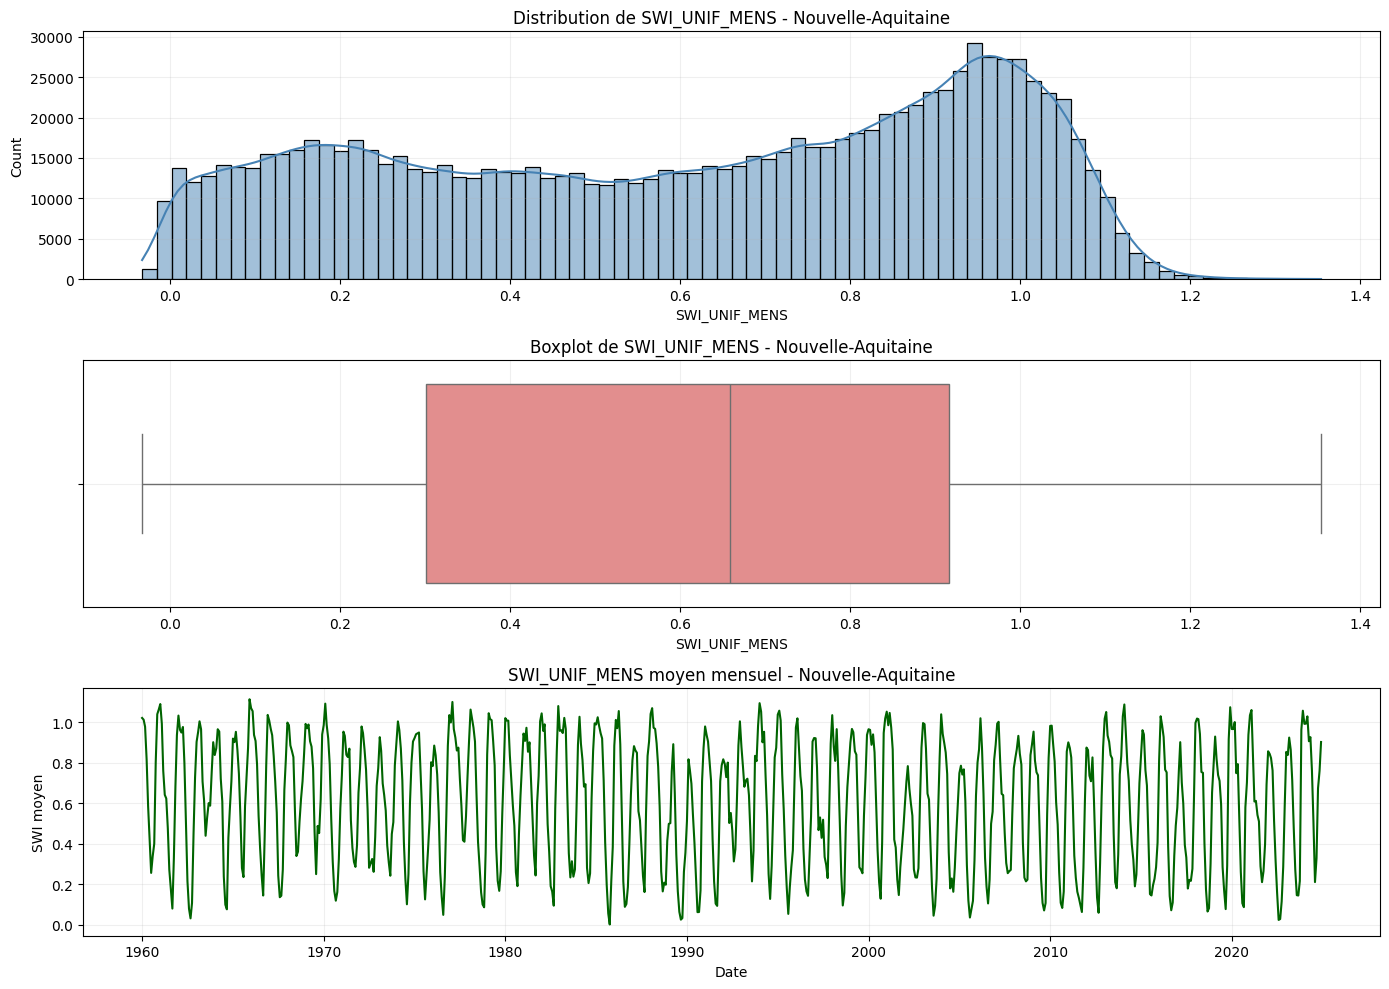

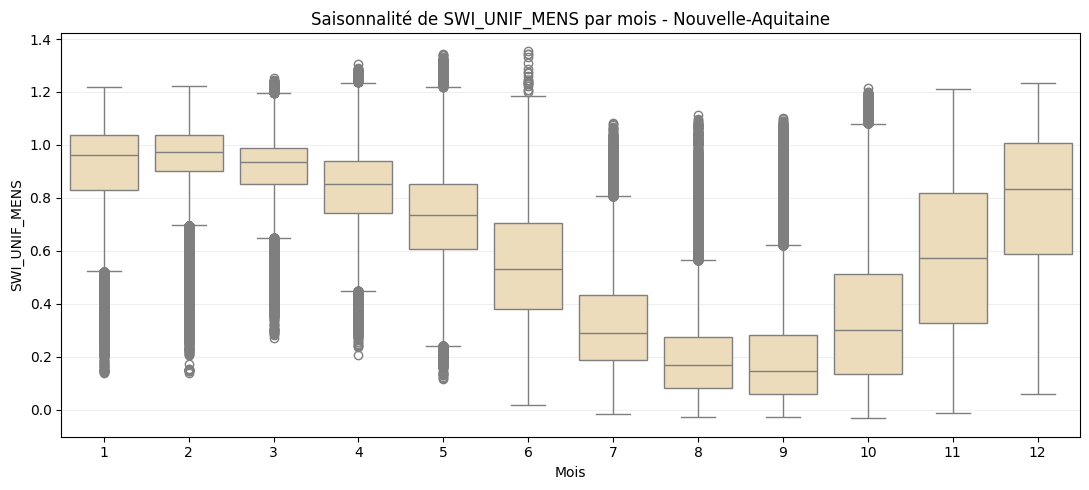

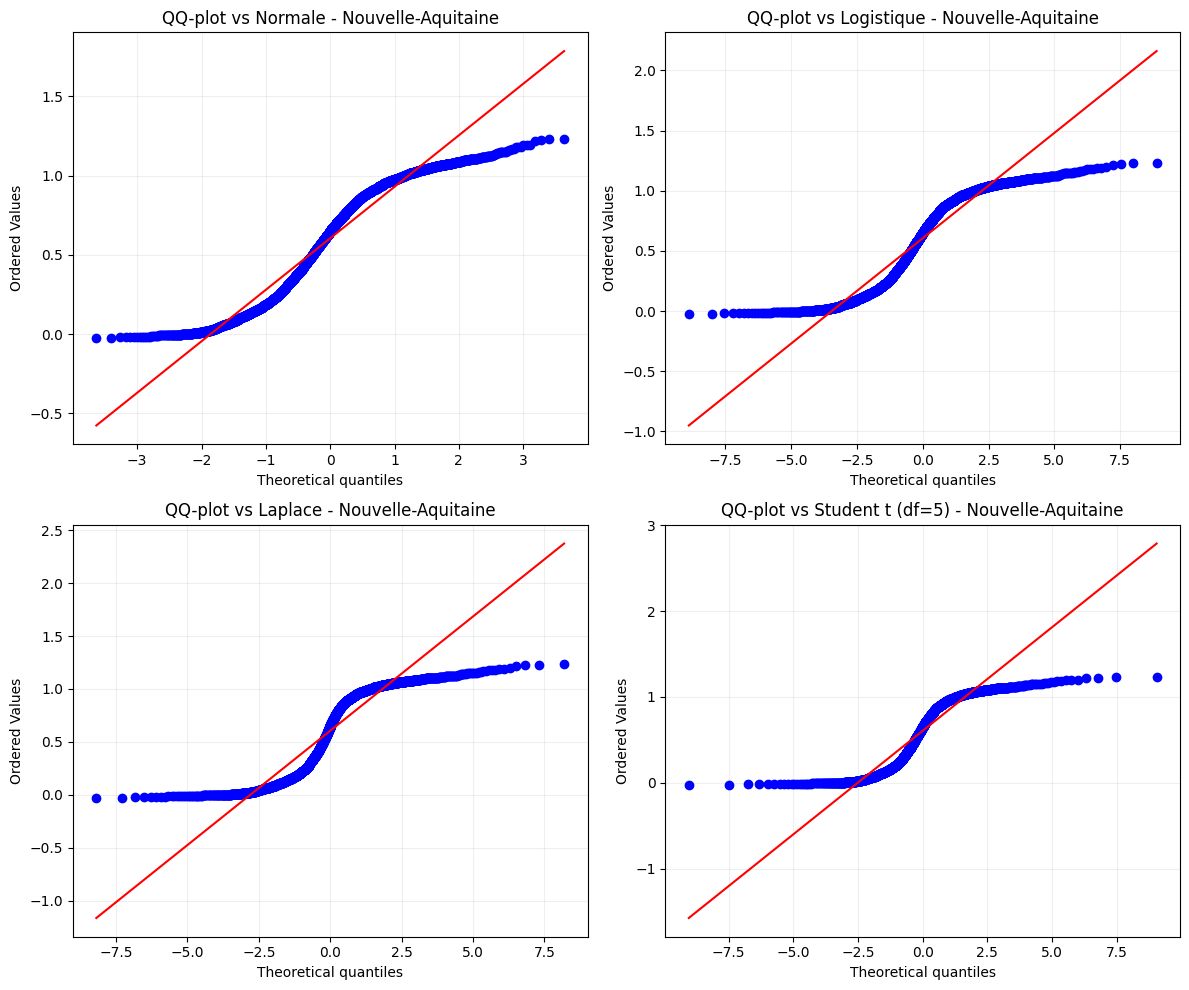

In [14]:
# Focus Nouvelle-Aquitaine : mêmes analyses descriptives + normalité + visualisations

region_name = "Nouvelle-Aquitaine"

# Vérification/création de REGION si nécessaire
if "REGION" not in gdf_joint_argile.columns:
    gdf_joint_argile["DPT"] = gdf_joint_argile["DPT"].astype(str).str.zfill(2)
    gdf_joint_argile["REGION"] = gdf_joint_argile["DPT"].map(dpt_to_region)

eda_na = gdf_joint_argile.loc[
    gdf_joint_argile["REGION"].eq(region_name),
    ["DATE", "SWI_UNIF_MENS"]
].copy()

eda_na["DATE"] = pd.to_datetime(eda_na["DATE"], errors="coerce")
eda_na["SWI_UNIF_MENS"] = pd.to_numeric(eda_na["SWI_UNIF_MENS"], errors="coerce")
eda_na = eda_na.dropna(subset=["DATE", "SWI_UNIF_MENS"])

if eda_na.empty:
    raise ValueError(f"Aucune donnée disponible pour la région {region_name}.")

swi_na = eda_na["SWI_UNIF_MENS"]

# --- Statistiques descriptives ---
desc_na = swi_na.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
iqr_na = desc_na["75%"] - desc_na["25%"]
lower_na = desc_na["25%"] - 1.5 * iqr_na
upper_na = desc_na["75%"] + 1.5 * iqr_na
outlier_rate_na = ((swi_na < lower_na) | (swi_na > upper_na)).mean() * 100

stats_table_na = pd.Series(
    {
        "count": swi_na.count(),
        "mean": swi_na.mean(),
        "median": swi_na.median(),
        "std": swi_na.std(),
        "variance": swi_na.var(),
        "min": swi_na.min(),
        "max": swi_na.max(),
        "q01": desc_na["1%"],
        "q05": desc_na["5%"],
        "q25": desc_na["25%"],
        "q50": desc_na["50%"],
        "q75": desc_na["75%"],
        "q95": desc_na["95%"],
        "q99": desc_na["99%"],
        "IQR": iqr_na,
        "skewness": swi_na.skew(),
        "kurtosis_fisher": swi_na.kurt(),
        "kurtosis_pearson": swi_na.kurt() + 3,
        "outlier_rate_IQR_%": outlier_rate_na,
    },
    name=f"SWI_UNIF_MENS ({region_name})"
)
display(stats_table_na.to_frame())

# --- Tests de normalité ---
sample_n_na = min(200_000, len(swi_na))
sample_na = swi_na.sample(sample_n_na, random_state=42)

k2_stat_na, k2_p_na = stats.normaltest(sample_na)
jb_stat_na, jb_p_na = stats.jarque_bera(sample_na)

shapiro_sample_na = sample_na.sample(min(5000, len(sample_na)), random_state=42)
sh_stat_na, sh_p_na = stats.shapiro(shapiro_sample_na)

normality_na = pd.DataFrame(
    {
        "test": ["D’Agostino K²", "Jarque-Bera", "Shapiro-Wilk"],
        "statistique": [k2_stat_na, jb_stat_na, sh_stat_na],
        "p_value": [k2_p_na, jb_p_na, sh_p_na],
    }
)
display(normality_na)

# --- Visualisations ---
fig_na, axes_na = plt.subplots(3, 1, figsize=(14, 10), squeeze=False)

sns.histplot(swi_na, bins=80, kde=True, ax=axes_na[0, 0], color="steelblue")
axes_na[0, 0].set_title(f"Distribution de SWI_UNIF_MENS - {region_name}")
axes_na[0, 0].set_xlabel("SWI_UNIF_MENS")
axes_na[0, 0].grid(alpha=0.2)

sns.boxplot(x=swi_na, ax=axes_na[1, 0], color="lightcoral")
axes_na[1, 0].set_title(f"Boxplot de SWI_UNIF_MENS - {region_name}")
axes_na[1, 0].set_xlabel("SWI_UNIF_MENS")
axes_na[1, 0].grid(alpha=0.2)

swi_monthly_na = eda_na.groupby(pd.Grouper(key="DATE", freq="MS"))["SWI_UNIF_MENS"].mean()
axes_na[2, 0].plot(swi_monthly_na.index, swi_monthly_na.values, color="darkgreen", linewidth=1.5)
axes_na[2, 0].set_title(f"SWI_UNIF_MENS moyen mensuel - {region_name}")
axes_na[2, 0].set_xlabel("Date")
axes_na[2, 0].set_ylabel("SWI moyen")
axes_na[2, 0].grid(alpha=0.2)

plt.tight_layout()
plt.show()

# --- Saisonnalité ---
eda_na["month"] = eda_na["DATE"].dt.month
plt.figure(figsize=(11, 5))
sns.boxplot(data=eda_na, x="month", y="SWI_UNIF_MENS", color="wheat")
plt.title(f"Saisonnalité de SWI_UNIF_MENS par mois - {region_name}")
plt.xlabel("Mois")
plt.ylabel("SWI_UNIF_MENS")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

# --- QQ-plots ---
distributions_na = [
    ("Normale", stats.norm, ()),
    ("Logistique", stats.logistic, ()),
    ("Laplace", stats.laplace, ()),
    ("Student t (df=5)", stats.t, (5,)),
]

fig_qq_na, axes_qq_na = plt.subplots(2, 2, figsize=(12, 10))
for ax_na, (dist_name_na, dist_na, sparams_na) in zip(axes_qq_na.flat, distributions_na):
    stats.probplot(shapiro_sample_na, dist=dist_na, sparams=sparams_na, plot=ax_na)
    ax_na.set_title(f"QQ-plot vs {dist_name_na} - {region_name}")
    ax_na.grid(alpha=0.2)

plt.tight_layout()
plt.show()